In [1]:
import os
print(os.getcwd())


C:\Users\poova\Machine Learning\crop


Mean Absolute Error: 1204282.21561755
Root Mean Squared Error: 20059004.98716349
R² Score: -6.431508544313402e-05


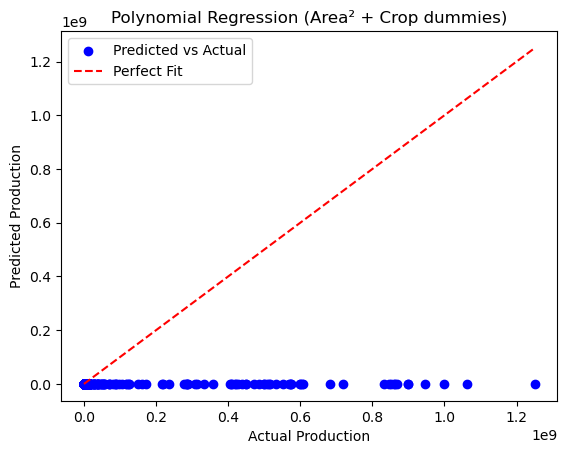

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\poova\Machine Learning\crop_production.csv")

# Features and target
X = df[['Crop', 'Area']]
y = df['Production']

# Encode categorical 'Crop'
X = pd.get_dummies(X, columns=['Crop'], drop_first=True)

# Ensure target is numeric
y = pd.to_numeric(y, errors='coerce')
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

# Separate numeric column 'Area' for polynomial expansion
area = X[['Area']]
poly = PolynomialFeatures(degree=8, include_bias=False)
area_poly = poly.fit_transform(area)

# Combine polynomial 'Area' with crop dummies
X_poly = np.hstack([area_poly, X.drop(columns=['Area']).values])

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)

# Accuracy metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

# Visualization
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Fit')
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Polynomial Regression (Area² + Crop dummies)")
plt.legend()
plt.show()


In [12]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)
print("Ridge R²:", ridge.score(x_test, y_test))

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)
print("Lasso R²:", lasso.score(x_test, y_test))


Ridge R²: 0.12928937515348427
Lasso R²: 0.1293219420838282


C:\Users\poova\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.228e+19, tolerance: 5.108e+15
  model = cd_fast.enet_coordinate_descent(


In [13]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0
...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,16250.0
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0
